A random variable $X \sim \mathcal{B}in(N,\mu)$ has probability mass function given by
$$ \mathcal{B}in(m\mid N,\mu) = \binom{N}{m} \mu^m (1-\mu)^{N-m} $$
and has expected value $\mathbb{E}[X] = N \mu$ and variance $\mathbb{V}[X] = N\mu(1-\mu)$.

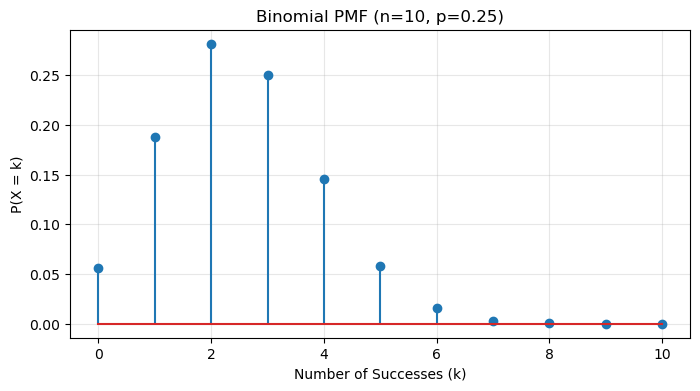

In [4]:
# Binomial distribution

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parameters
n = 10          # number of trials
p = 0.25        # probability of success

# Values of k (number of successes)
x = np.arange(0, n + 1)

# PMF: P(X = k)
pmf_vals = binom.pmf(x, n, p)

# Plot
plt.figure(figsize=(8, 4))
plt.stem(x, pmf_vals)
plt.xlabel("Number of Successes (k)")
plt.ylabel("P(X = k)")
plt.title(f"Binomial PMF (n={n}, p={p})")
plt.grid(True, alpha=0.3)
plt.show()

A random variable $X \sim \mathcal{B}eta(a,b)$ has probability density function given by
$$ \mathcal{B}eta(\mu \mid a,b) = \frac{\Gamma(a+b)}{\Gamma(a)\Gamma(b)} \mu^{a-1} (1-\mu)^{b-1} $$
and has expected value $\mathbb{E}[X] = a/(a+b)$ and $\mathbb{V}[X] = ab/[(a+b)^2(a+b+1)]$.

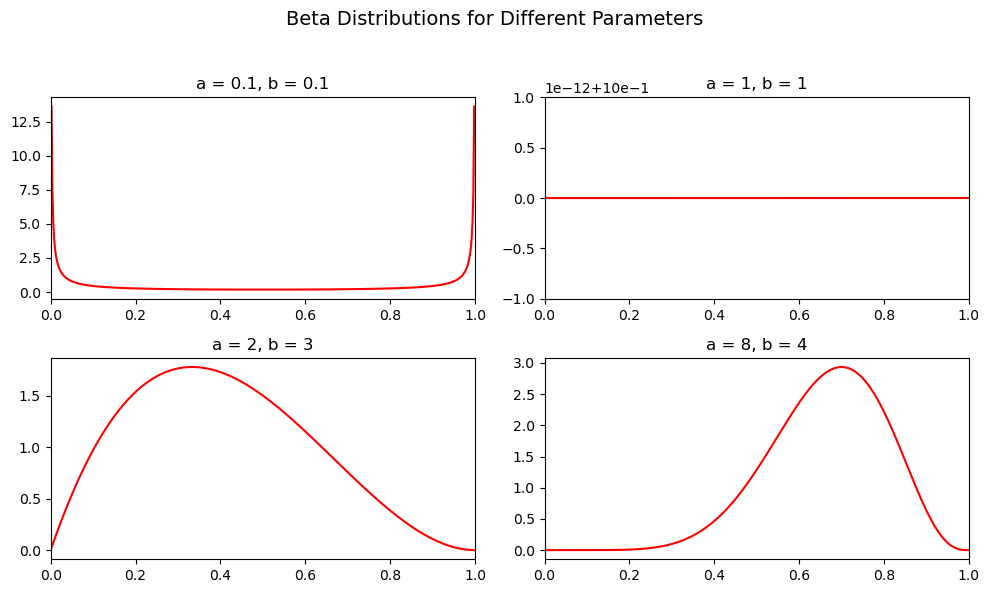

In [4]:
# Beta distribution

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

param_sets = [
    (0.1, 0.1),  # U-shaped
    (1, 1),      # Bell-shaped
    (2, 3),      # Skewed right
    (8, 4)       # Skewed left
]

# x-axis range
x = np.linspace(0, 1, 500)

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for ax, (a, b) in zip(axes.flat, param_sets):
    pdf = beta.pdf(x, a, b)
    ax.plot(x, pdf, color='red')
    ax.set_title(fr'a = {a}, b = {b}')
    ax.set_xlim(0, 1)

plt.suptitle('Beta Distributions for Different Parameters', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


The Beta-Binomial distribution as as posterior of the Binomial model when a Beta prior is chosen for the probability $\mu$. Indeed, given $X\mid \mu\sim \mathcal{B}in(N,\mu)$ and $\mu \sim \mathcal{B}eta(a,b)$, from Bayes' theorem
$$ p(\mu \mid X) \propto \mu^{m}(1-\mu)^{N-m} \mu^{a-1}(1-\mu)^{b-1} = \mu^{a+m-1} (1-\mu)^{b + (N-m) -1} $$
which results in $\mu \mid X \sim \mathcal{B}eta(a+m, b+(N-m))$.

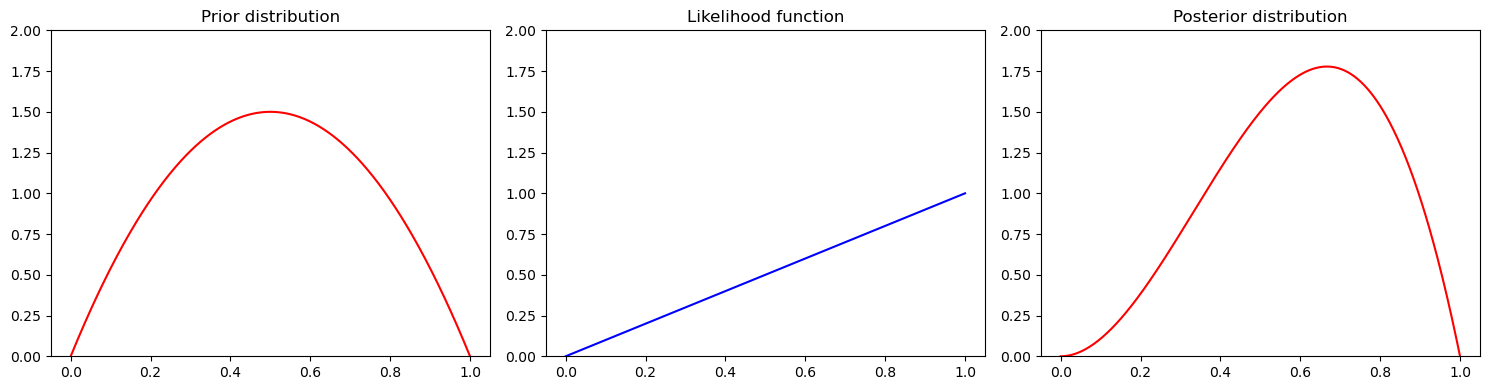

In [5]:
# Binomial-Beta distribution

a_prior = 2
b_prior = 2

m = 1

x = np.linspace(0, 1, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Prior distribution
pdf_prior = beta.pdf(x, a_prior, b_prior)
axes[0].plot(x, pdf_prior, color='red')
axes[0].set_title('Prior distribution')
axes[0].set_ylim(0, 2)

# Likelihood function
axes[1].plot(x, x, color='blue')
axes[1].set_title('Likelihood function')
axes[1].set_ylim(0, 2)

# Posterior distribution
a_posterior = a_prior + m
b_posterior = b_prior + 0
pdf_posterior = beta.pdf(x, a_posterior, b_posterior)
axes[2].plot(x, pdf_posterior, color='red')
axes[2].set_title('Posterior distribution')
axes[2].set_ylim(0, 2)

plt.tight_layout()
plt.show()

The Dirichlet distribution arises as multivariate generaliation of the Beta distribution. A random variable $\boldsymbol{\mu} \sim \mathcal{D}ir(\boldsymbol{\alpha})$ has probability density function given by
$$ \mathcal{D}ir(\boldsymbol{\mu} \mid \boldsymbol\alpha) = \frac{\alpha_0}{\Gamma(\alpha_1)\cdots \Gamma(\alpha_K)} \prod_{k=1}^K \mu_k^{\alpha_k-1} $$
where $\alpha_0 = \sum_{k=1}^K \alpha_k$ and has expected value $\mathbb{E}[\mu_k] = \alpha_k/\alpha_0$ and variance $\mathbb{V}[\mu_k] = \alpha_k (\alpha_0 - \alpha_k) / [\alpha_0^2(1+\alpha_0)]$.

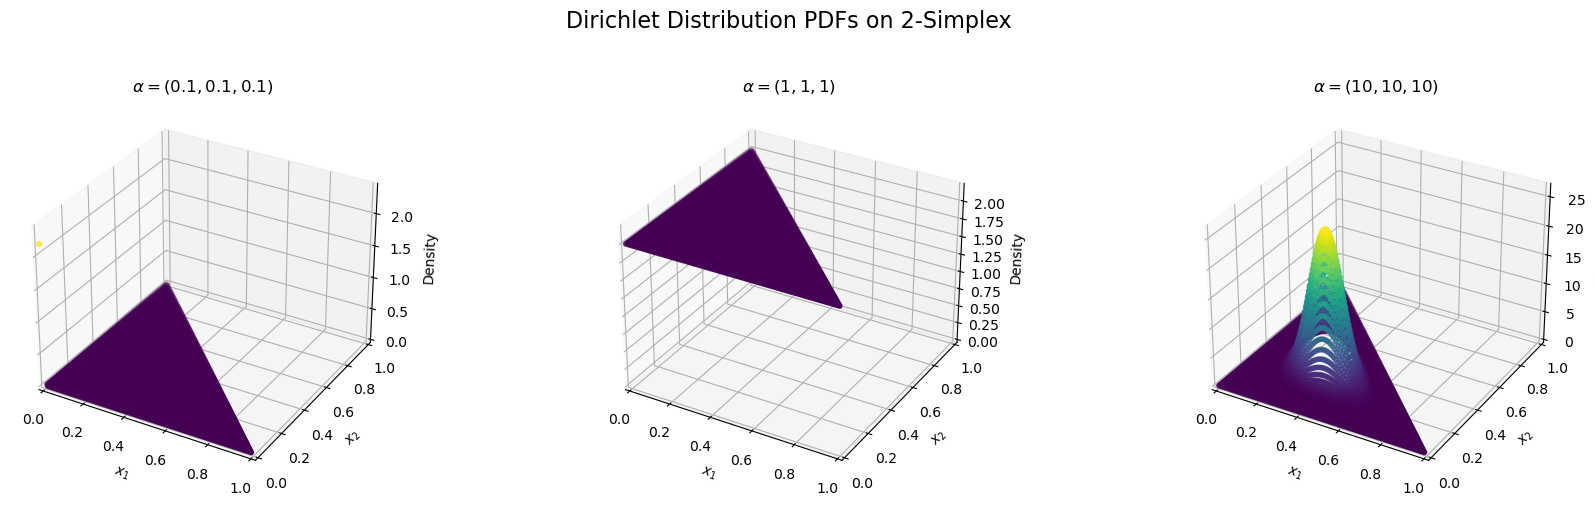

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import dirichlet
from mpl_toolkits.mplot3d import Axes3D  # for 3D plotting

def simplex_points(n=100):
    x = np.linspace(0, 1, n)
    y = np.linspace(0, 1, n)
    X, Y = np.meshgrid(x, y)
    mask = X + Y <= 1
    X_simplex = X[mask]
    Y_simplex = Y[mask]
    return X_simplex, Y_simplex

def compute_dirichlet_pdf(alpha, X, Y, epsilon=1e-6):
    # Clip x1 and x2 away from boundaries to avoid zero values
    X_safe = np.clip(X, epsilon, 1 - epsilon)
    Y_safe = np.clip(Y, epsilon, 1 - epsilon)
    
    # Recalculate x3 exactly so sum = 1 - (x1 + x2)
    Z_safe = 1 - X_safe - Y_safe
    
    # Filter points where x3 is valid (not too close to 0 or 1)
    valid = (Z_safe >= epsilon) & (Z_safe <= 1 - epsilon)
    
    X_valid = X_safe[valid]
    Y_valid = Y_safe[valid]
    Z_valid = Z_safe[valid]
    
    points = np.vstack([X_valid, Y_valid, Z_valid]).T
    
    # Evaluate Dirichlet PDF pointwise
    pdf_vals = np.array([dirichlet.pdf(point, alpha) for point in points])
    
    return X_valid, Y_valid, pdf_vals

# Dirichlet alpha parameters for plots
alphas = [
    (0.1, 0.1, 0.1),
    (1, 1, 1),
    (10, 10, 10)
]

X, Y = simplex_points(n=100)

fig = plt.figure(figsize=(18, 5))

for i, alpha in enumerate(alphas, 1):
    ax = fig.add_subplot(1, 3, i, projection='3d')
    
    X_plot, Y_plot, pdf_vals = compute_dirichlet_pdf(alpha, X, Y)
    
    sc = ax.scatter(X_plot, Y_plot, pdf_vals, c=pdf_vals, cmap='viridis', marker='o', s=10)
    
    ax.set_title(r'$\alpha = ({},{},{})$'.format(*alpha))
    ax.set_xlabel(r'$x_1$')
    ax.set_ylabel(r'$x_2$')
    ax.set_zlabel('Density')
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_zlim(0, np.max(pdf_vals)*1.1)

plt.suptitle('Dirichlet Distribution PDFs on 2-Simplex', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


The (laplace's) Central Limit Theorem tells us that, subject to certain mild conditions, the sum of a set of random variables has a distribution that becomes increasingly Gaussian as the number of terms in the sum increase We illustrate this by considering $N$ variables $X_1, \dots, X_N \sim \mathcal{U}(0,1)$ and computing the sample mean $\bar{x}_N = N^{-1}\sum_{n=1}^N x_n$.

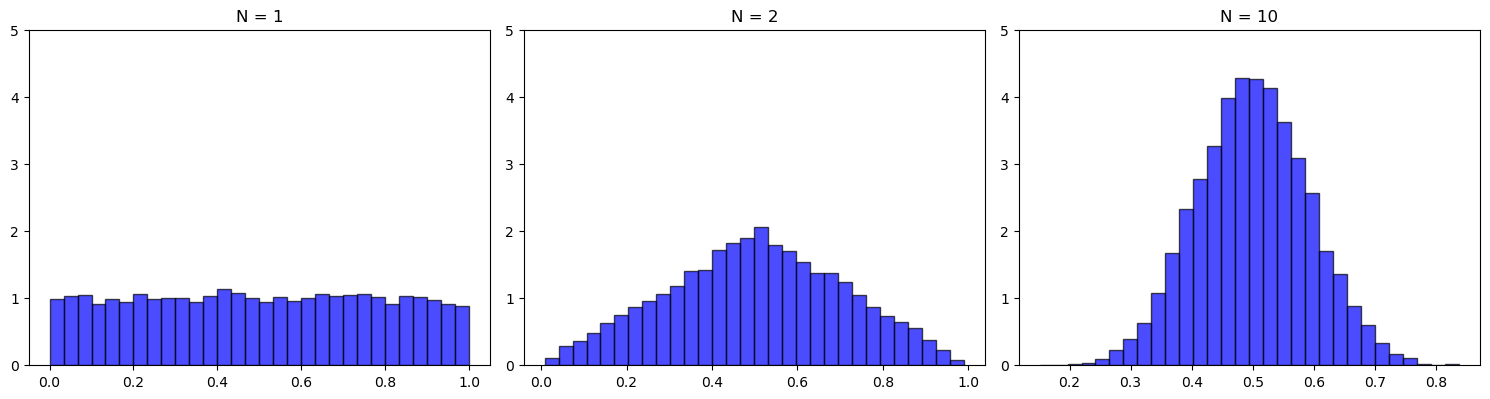

In [7]:
# Convergence of the sample mean

Ns = [1, 2, 10]
num_samples = 10000     # Number of mean samples to draw

plt.figure(figsize=(15, 8))

for i, N in enumerate(Ns, 1):
    samples = np.mean(np.random.uniform(0, 1, size=(num_samples, N)), axis=1)
    
    plt.subplot(2, 3, i)
    plt.hist(samples, bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')
    plt.ylim(0,5)    
    plt.title(f'N = {N}')
    

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


The functional dependence of the Gaussian on $\mathbf{x}$ is through the quadratic form $\Delta^2 = (\mathbf{x} - \bm\mu)^\top \bm\Sigma^{-1} (\mathbf{x} - \bm\mu)$, where $\Delta$ is sometimes called Mahalanobis distance. We consider the eigenvalues $\lambda_i$ and eigenvectors $\mathbf{u}_i$ from $\bm\Sigma \mathbf{u}_i = \lambda_i \mathbf{u}_i$, setting $y_i = \mathbf{u}_i^\top(\mathbf{x} - \bm\mu)$ we can interpret $\{y_i\}$ as a new coordinate system defined by the orthonormal vectors $\mathbf{u}_i$ that are shifted and rotated with respect to the original $x_i$ coordinates.

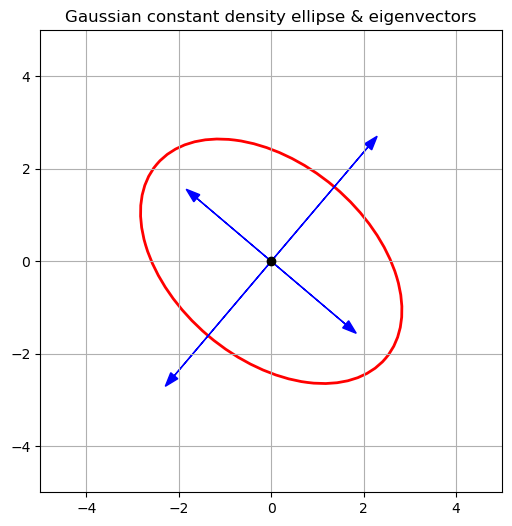

In [8]:
# Contour of Multivariate Gaussian Random Variable

from matplotlib.patches import Ellipse

# Mean and covariance
mu = np.array([0, 0])
Sigma = np.array([[7, 3],
                  [3, 8]])

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(Sigma)

# Ellipse width and height (diameters)
width, height = 2 * np.sqrt(eigvals)

# Angle of ellipse in degrees
angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))

fig, ax = plt.subplots(figsize=(6,6))

# Plot ellipse (constant Mahalanobis distance = 1 contour)
ellipse = Ellipse(xy=mu, width=width, height=height, angle=angle,
                  edgecolor='red', fc='none', lw=2)
ax.add_patch(ellipse)

# Plot eigenvectors as arrows
for i in range(2):
    vec = eigvecs[:, i] * np.sqrt(eigvals[i])
    ax.arrow(mu[0], mu[1], vec[0], vec[1],
             head_width=0.2, head_length=0.3, fc='blue', ec='blue')
    ax.arrow(mu[0], mu[1], -vec[0], -vec[1],
             head_width=0.2, head_length=0.3, fc='blue', ec='blue')

ax.plot(mu[0], mu[1], 'o', color='black')

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.set_title('Gaussian constant density ellipse & eigenvectors')
plt.grid(True)
plt.show()

Contours of constant probability density for a Gaussian distribution in two dimensions in which the covariance matrix is full, diagonal and isotropic respectively.

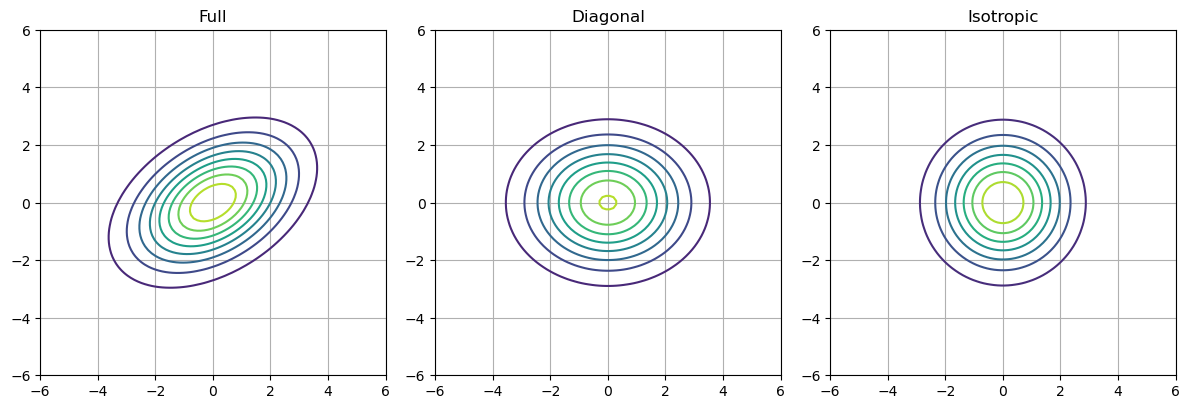

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

mu = [0, 0]

# Covariance matrices
Sigma_full = [[3, 1],
              [1, 2]]

Sigma_diag = [[3, 0],
              [0, 2]]

Sigma_iso = [[2, 0],
             [0, 2]]

x = np.linspace(-6, 6, 100)
y = np.linspace(-6, 6, 100)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

covs = [Sigma_full, Sigma_diag, Sigma_iso]
titles = ['Full', 'Diagonal', 'Isotropic']

for ax, cov, title in zip(axs, covs, titles):
    rv = multivariate_normal(mu, cov)
    Z = rv.pdf(pos)
    ax.contour(X, Y, Z, levels=8)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.grid(True)

plt.tight_layout()
plt.show()


Sequential methods allow data points to be processed one at a time and then discarded and are important for on-line applications. The Robbins-Monro algorithm in a simplifies setting yields the following updates:
$$ \bm\mu_{ML}^{(N)} = \frac{1}{N} \sum_{n=1}^N \mathbf{x}_n = \frac{1}{N} \mathbf{x}_N + \frac{1}{N}\sum_{n=1}^{N-1} \mathbf{x}_n = \frac{1}{N} \mathbf{x}_N + \frac{N-1}{N}\bm\mu_{ML}^{(N-1)} = \bm\mu_{ML}^{(N-1)} + \frac{1}{N}(\mathbf{x}_N - \bm\mu_{ML}^{(N-1)}) $$

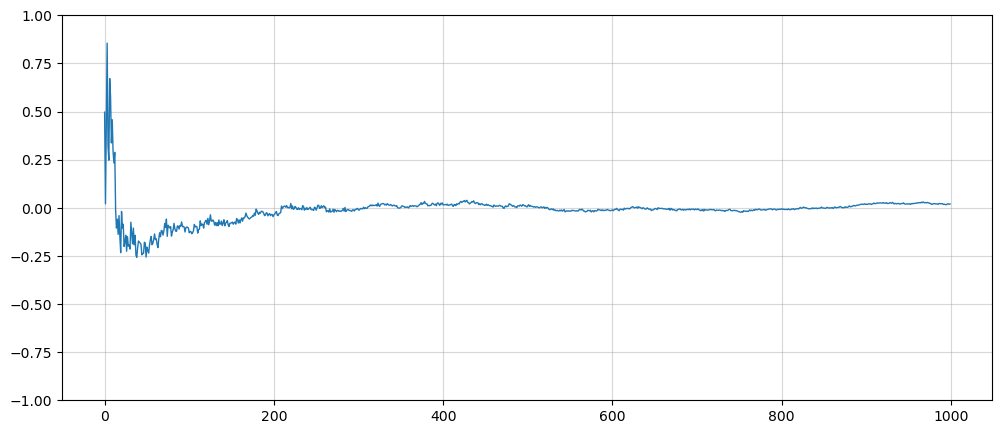

In [10]:
# Roobinson-Monro alorithm

np.random.seed(42)
sample = np.random.randn(1000)

sum_s = sample[0]
theta_n = sum_s / 1
hist = [theta_n]
for N, s in enumerate(sample[1:], 2):
    sum_s += s
    theta_n = sum_s / N + 1 / N * (s - sum_s / N)
    hist.append(theta_n)

plt.figure(figsize=(12,5))
plt.plot(hist, linewidth=1)
plt.ylim(-1, 1)
plt.grid(alpha=0.5)

As we saw before, a Gaussian model with unknwon mean with a Gaussian prior on top of it yields a Gaussian posterior distribution with updated parameters. Given $X_n\mid \mu \sim \mathcal{N}(\mu, \sigma^2)$ for $n = 1,\dots,N$ and $\mu \sim \mathcal{N}(\mu_0,\sigma_0^2)$, then similar computations as before get us
$$ \ln p(\mu\mid \mathbf{X}) \propto - \frac{1}{2\sigma^2} \sum_{n=1}^N (X_n-\mu)^2 -\frac{1}{2\sigma_0^2}(\mu- \mu_0 )^2 \propto - \frac{1}{2} [\sigma^{-2}N \mu^2 - 2 \sigma^{-2} \mu N \bar{x}_N + \sigma_0^{-2} \mu^2 -2 \sigma_0^{-2}\mu_0\mu] = - \frac{1}{2} [(\sigma^2 N + \sigma_0)\mu^2 - 2(\sigma^{-2}N \bar{x}_N + \sigma_0^{-2}\mu_0)\mu ] $$
which yields, by completing the square,
$$\mu \mid \mathbf{X} \sim \mathcal{N}\left( \frac{\sigma^{-2}N \bar{x}_N + \sigma_0^{-2}\mu_0}{\sigma^2 N + \sigma_0} , (\sigma^2 N + \sigma_0)^{-1}\right)$$
which respects the classical result that the expected value is a convex combination of prior mean and sample mean.

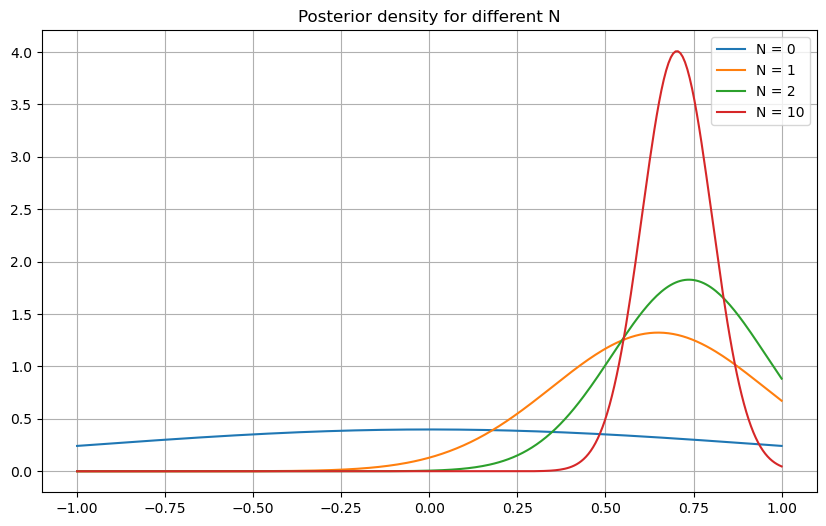

In [11]:
# Gaussian-Gaussian distribution

from scipy.stats import norm

# Known parameters
mu_true = 0.8
sigma_data = np.sqrt(0.1)  # std dev of data distribution
mu0 = 0.0                  # prior mean
sigma0 = 1.0               # prior std dev

# Generate a large pool of data points from true distribution
np.random.seed(41)
data_pool = np.random.normal(mu_true, sigma_data, size=1000)

# Different numbers of observed data points
N_values = [0, 1, 2, 10]

x_range = np.linspace(-1, 1, 300)

plt.figure(figsize=(10,6))

for N in N_values:
    if N > 0:
        observed = data_pool[:N]
        x_bar = np.mean(observed)
    else:
        x_bar = 0  # no data for prior
    
    # Posterior variance and mean
    sigmaN_squared = 1 / (1/sigma0**2 + N / sigma_data**2)
    sigmaN = np.sqrt(sigmaN_squared)
    muN = sigmaN_squared * (mu0 / sigma0**2 + N * x_bar / sigma_data**2)
    
    # Plot prior/posterior
    label = f'N = {N}'
    plt.plot(x_range, norm.pdf(x_range, muN, sigmaN), label=label)

plt.title('Posterior density for different N')
plt.legend()
plt.grid(True)
plt.show()

A random variable $X \sim \mathcal{G}amma(a,b)$ has probability density function
$$ \mathcal{G}amma(\lambda\mid a,b) = \frac{b^a}{\Gamma(a)} \lambda^{a-1} e^{-b\lambda} $$
and expected value $\mathbb{E}[X] = a/b$ and variance $\mathbb{V}[X] = a/b^2$.

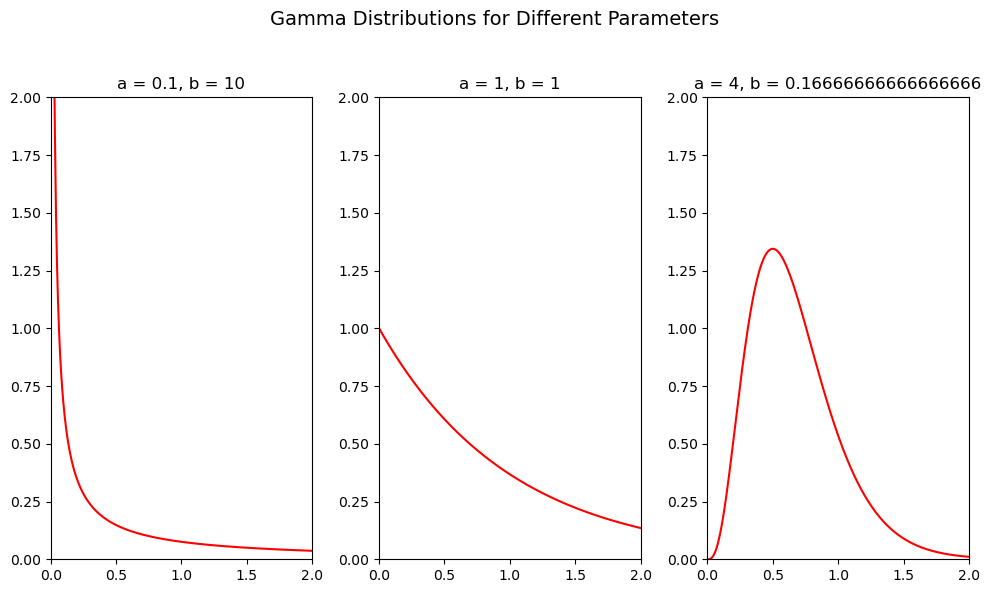

In [12]:
# Gamma distribution
from scipy.stats import gamma

param_sets = [
    (0.1, 10 ),
    (1, 1), 
    (4,  1/6)
]

# x-axis range
x = np.linspace(0, 2, 500)

# Create 2x2 subplot
fig, axes = plt.subplots(1, 3, figsize=(10, 6))

for ax, (a, b) in zip(axes.flat, param_sets):
    pdf = gamma.pdf(x, a = a, scale = b)
    ax.plot(x, pdf, color='red')
    ax.set_title(fr'a = {a}, b = {b}')
    ax.set_xlim(0,2)
    ax.set_ylim(0,2)


plt.suptitle('Gamma Distributions for Different Parameters', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Assume both mean and precision (inverse of the variance) are unknown ina Gaussian model, i.e. $X_n\mid\mu, \lambda\sim \mathcal{N}(\mu,\lambda^{-1})$ (where $\lambda = \sigma^{-2}$), for $n = 1,\dots,N$, and we want to perform posterior inference. The likelihood is given by
$$ p(\mathbf{X}\mid\mu,\lambda) = \prod_{n=1}^N \left( \frac{\lambda}{2\pi} \right)^{1/2} \exp\left( -\frac{\lambda}{2}\sum_{n=1}^N (x_n-\mu)^2 \right) \propto \left(\lambda^{1/2} \exp(−\lambda\mu^2/2)\right)^N \exp\left( \lambda\mu \sum_{n=1}^N x_n − \frac{\lambda}{2} \sum_{n=1}^N x_n^2\right) $$
We want to find a prior distribution $p(\mu, \lambda)$ that mirrors the functional dependence of the likelihood. We start with the uncompleted form based on hyperparameters $\beta, c,$ and $d$:
$$ p(\mu, \lambda) \propto \left[ \lambda^{1/2} \exp \left( -\frac{\lambda \mu^2}{2} \right) \right]^\beta \exp (c \lambda \mu - d \lambda) = \exp\left( - \frac{\beta\lambda}{2} (\mu- c/\beta)^2 \right) \lambda^{\beta/2} \exp\left(- (d- \frac{c^2}{2\beta})\lambda \right) $$
Since we can always write $p(\mu, \lambda) = p(\mu\mid\lambda)p(\lambda)$, we can find $p(\mu\mid \lambda)$ and $p(\lambda)$ by inspection, yielding $p(\mu, \lambda) = \mathcal{N} (\mu\mid\mu_0, (\beta\lambda)^{−1})\mathcal{G}amma(\lambda\mid a, b)$, where $\mu_0 = c/\beta$, $a = 1+\beta/2$ and $b = d - c^2/(2\beta)$.

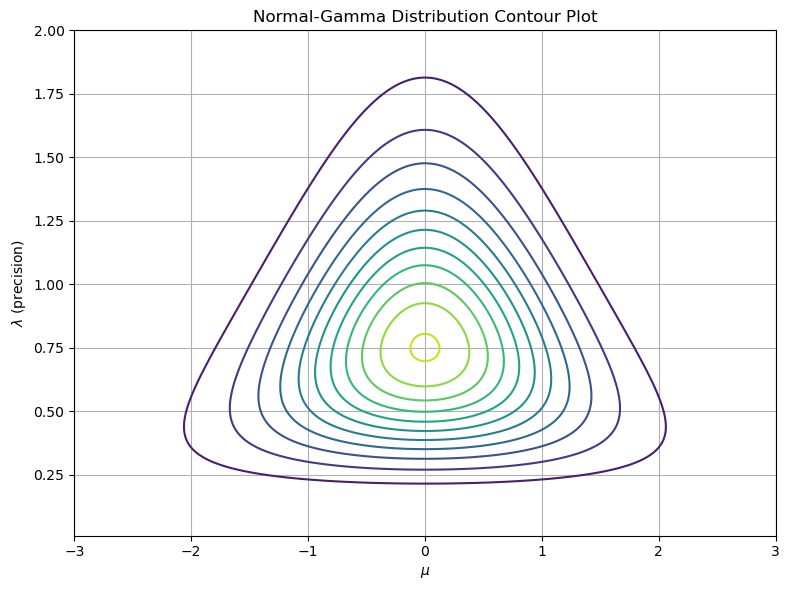

In [13]:
# Gaussian-Gamma distribution

mu0 = 0
beta = 2
a = 5
b = 6 

mu_vals = np.linspace(-3, 3, 300)
lambda_vals = np.linspace(0.01, 2, 300)
MU, LAMBDA = np.meshgrid(mu_vals, lambda_vals)

# Compute joint PDF: Normal-Gamma
normal_pdf = norm.pdf(MU, loc=mu0, scale=np.sqrt(1 / (beta * LAMBDA)))
gamma_pdf = gamma.pdf(LAMBDA, a=a, scale=1 / b)
Z = normal_pdf * gamma_pdf  # joint density

# Plot in your preferred style
fig, ax = plt.subplots(figsize=(8, 6))

contours = ax.contour(MU, LAMBDA, Z, levels=12, cmap='viridis')

ax.set_title('Normal-Gamma Distribution Contour Plot')
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$\lambda$ (precision)')
ax.set_aspect('auto')
ax.grid(True)

plt.tight_layout()
plt.show()


A random variable $X \sim \mathcal{S}t(\mu,\lambda,\nu)$ has probability density function
$$ \mathcal{S}t(x\mid \mu,\lambda,\nu) = \frac{\Gamma(\nu/2+1/2)}{\Gamma(\nu/2)}\left( \frac{\lambda}{\pi\nu} \right)^{1/2} \left( 1+ \frac{\lambda(x-\mu)^2}{\nu} \right)^{-\nu/2-1/2} $$
and has expected value $\mathbb{E}[X] = \mu$ and variance $\mathbb{V}[X] = \nu/[\lambda(\nu-2)]$ for $\nu>2$.

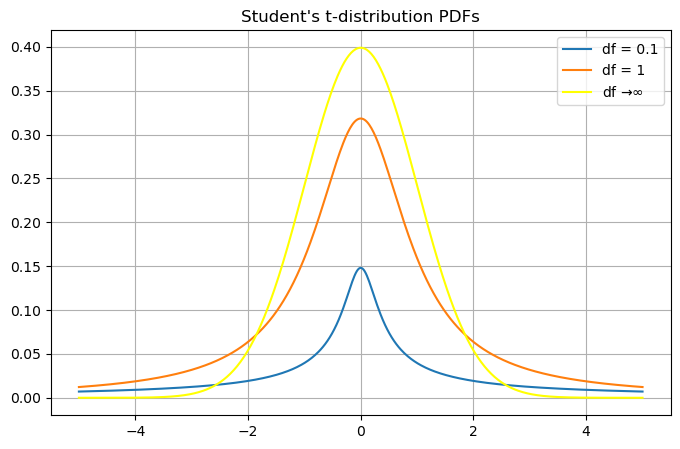

In [ ]:
# Student-t distribution
from scipy.stats import t

x = np.linspace(-5, 5, 500)

dfs = [0.1, 1]  # degrees of freedom

plt.figure(figsize=(8, 5))
for df in dfs:
    plt.plot(x, t.pdf(x, df), label=f'df = {df}')

plt.plot(x, t.pdf(x, np.inf),label= rf'df $\to \infty$', color = 'yellow')
plt.title("Student's t-distribution PDFs")
plt.legend()
plt.grid(True)
plt.show()

The $t$-Student distribution is often used as alternative of the Gaussian (which however is regained as $\nu\to\infty$) to better model outliers. This is caused by the heavier tails of this distribution, with respect to the Gaussian's tails, which gives the "robustness" property.

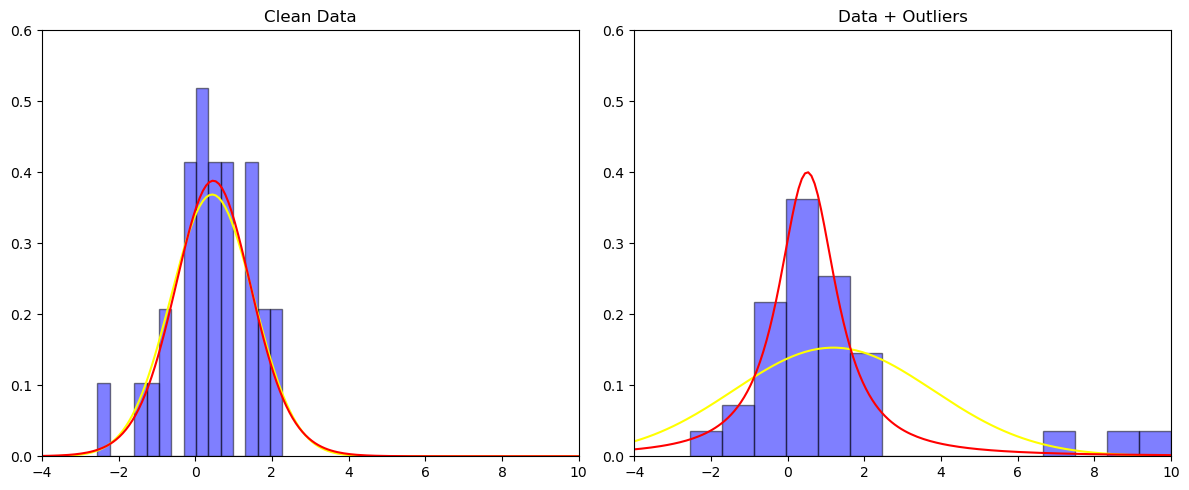

In [136]:
np.random.seed(0)

data_clean = np.random.normal(loc=0, scale=1, size=30)
data_outliers = np.append(data_clean, [10, 9, 7])  # Add 3 strong outliers

# Function to fit and plot both Gaussian and t-distributions
def plot_fit(data, ax, title):
    # Fit the data
    mu_gauss, std_gauss = norm.fit(data)
    df_t, mu_t, scale_t = t.fit(data)

    # Plot histogram
    ax.hist(data, bins=15, density=True, alpha=0.5, color='blue', edgecolor='k')

    # x-axis for plotting
    x = np.linspace(-10, 15, 300)

    ax.plot(x, norm.pdf(x, mu_gauss, std_gauss), color = 'yellow')
    ax.plot(x, t.pdf(x, df_t, mu_t, scale_t), color = 'red')
    ax.set_xlim(-4,10)
    ax.set_ylim(0,0.6)
    ax.set_title(title)

# Plot both cases side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

plot_fit(data_clean, axs[0], "Clean Data")
plot_fit(data_outliers, axs[1], "Data + Outliers")

plt.tight_layout()
plt.show()


There are situations in which they are inappropriate as density models for continuous variables, but periodic variables may be used, e.g. a periodic variable would be the wind direction at a particular geographical location.

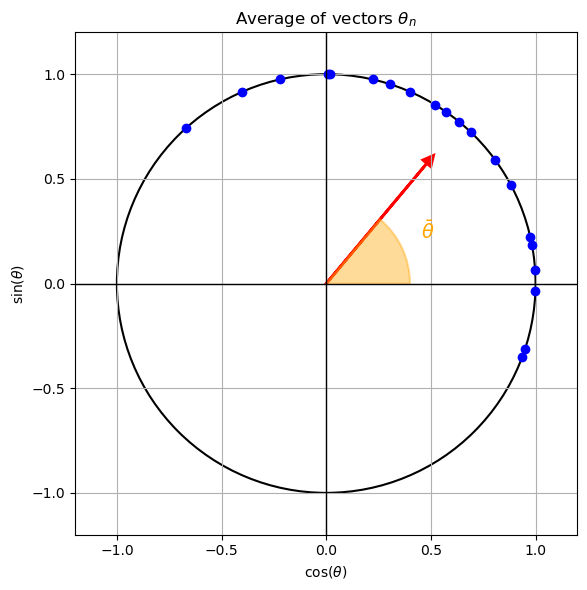

In [ ]:
# Von Mises distribution
from matplotlib.patches import Wedge

# Generate angles
np.random.seed(0)
N = 20
theta = np.random.vonmises(mu=np.pi/4, kappa=2, size=N)

# Convert to unit circle points
x = np.cos(theta)
y = np.sin(theta)

# Mean resultant vector and angle
mean_x = np.mean(x)
mean_y = np.mean(y)
mean_angle = np.arctan2(mean_y, mean_x)
mean_length = np.sqrt(mean_x**2 + mean_y**2)

# Plot setup
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)

# Draw unit circle
circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=1.5)
ax.add_artist(circle)

# Plot data points
ax.plot(x, y, 'o', color='blue', label='Data points')

# Mean vector
ax.arrow(0, 0, mean_x, mean_y,
         head_width=0.05, head_length=0.05,
         fc='red', ec='red', linewidth=2, label='Mean vector')

# X and Y axes
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

# Filled angle (from 0 to mean angle)
theta_degrees = np.degrees(mean_angle)
if theta_degrees < 0:
    theta_degrees += 360  # ensure it's in [0, 360]

wedge = Wedge(center=(0, 0),
              r=0.4,
              theta1=0,
              theta2=theta_degrees,
              facecolor='orange',
              alpha=0.4,
              edgecolor='orange',
              linewidth=1.5)
ax.add_patch(wedge)

# Annotate angle
ax.text(0.5 * np.cos(mean_angle / 2),
        0.5 * np.sin(mean_angle / 2),
        r'$\bar{\theta}$',
        fontsize=14, color='orange')

# Labels and legend
ax.set_title(rf'Average of vectors $\theta_n$')
ax.set_xlabel(r'$\cos(\theta)$')
ax.set_ylabel(r'$\sin(\theta)$')
ax.grid(True)

plt.tight_layout()
plt.show()


A random variable $X \sim \mathcal{VM}(\theta_0,m)$ has probability density function
$$ \mathcal{VM}(\theta\mid \theta_0, m) = \frac{1}{2\pi I_0(m)} \exp(m \cos (\theta - \theta_0) ) $$
where $I_0(\cdot)$ is zeroth-order Bessel function of the first kind.

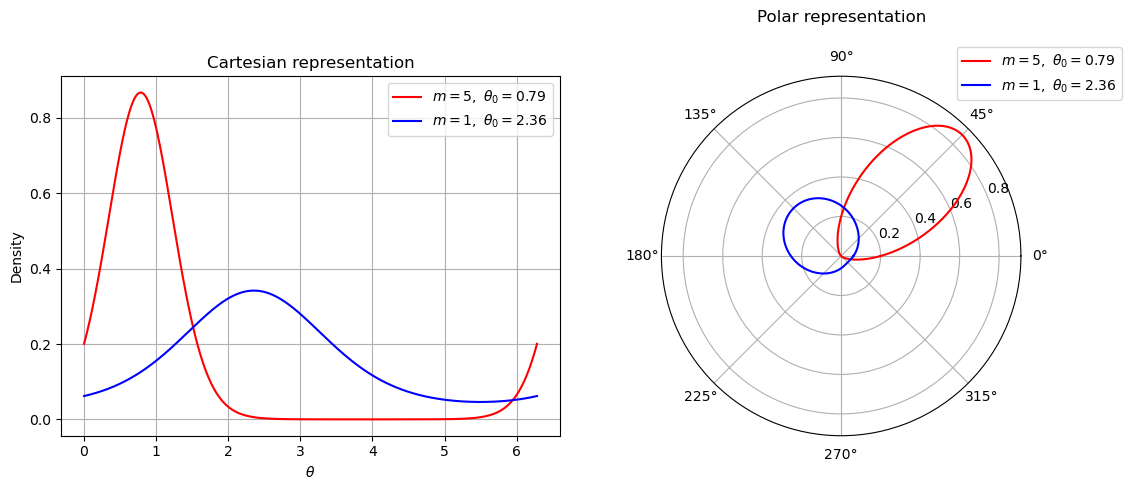

In [165]:
from scipy.stats import vonmises

# Angle grid
theta = np.linspace(0, 2 * np.pi, 500)

# Parameters: (mu, theta_0)
params = [
    (5, np.pi / 4),     # peaked
    (1, 3 * np.pi / 4)  # wider
]

# Colors
colors = ['red', 'blue']

# Compute PDFs
pdfs = [vonmises.pdf(theta, m, loc=theta_0) for m, theta_0 in params]

# Create figure
fig = plt.figure(figsize=(12, 5))

# Cartesian subplot (left)
ax1 = fig.add_subplot(1, 2, 1)
for pdf, (m, theta_0), color in zip(pdfs, params, colors):
    ax1.plot(theta, pdf, color=color, label=fr'$m={m},\ \theta_0={theta_0:.2f}$')
ax1.set_title("Cartesian representation")
ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel('Density')
ax1.legend()
ax1.grid(True)

# Polar subplot (right)
ax2 = fig.add_subplot(1, 2, 2, projection='polar')
for pdf, (m, theta_0), color in zip(pdfs, params, colors):
    ax2.plot(theta, pdf, color=color, label=fr'$m={m},\ \theta_0={theta_0:.2f}$')
ax2.set_title("Polar representation", pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()


Some functionals of interest in this setting are given by
$$I_0(m) = \frac{1}{2\pi} \int_0^{2\pi} \exp(m\cos (\theta-\theta_0))\, d\theta, \quad A(m) = \frac{I_1(m)}{I_0(m)} $$

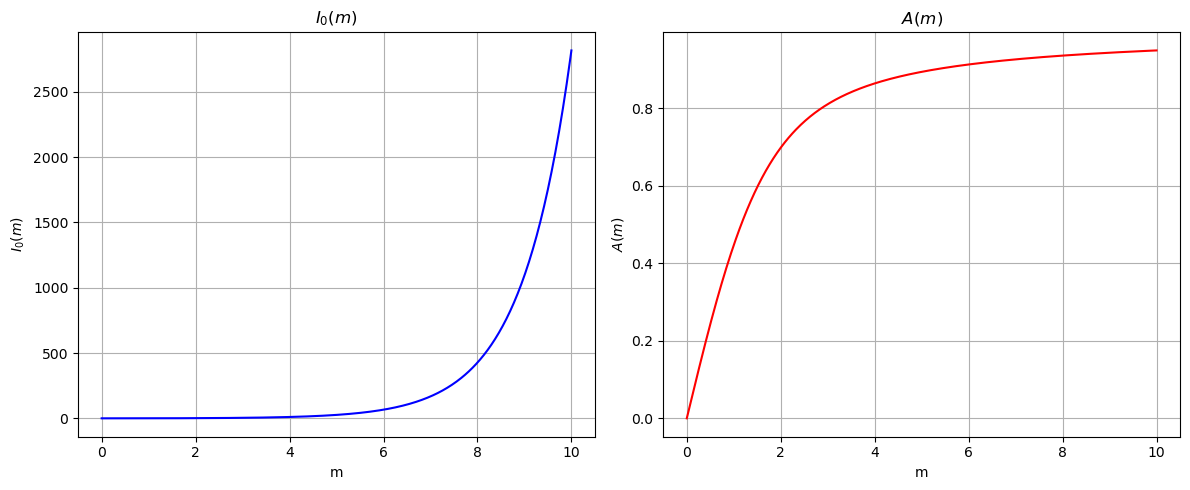

In [167]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import i0, i1

# Values of m (concentration parameter)
m = np.linspace(0, 10, 500)

# Compute I0(m) and A(m)
I0 = i0(m)
A_m = i1(m) / I0

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot I0(m)
ax[0].plot(m, I0, color='blue')
ax[0].set_title(r'$I_0(m)$')
ax[0].set_xlabel('m')
ax[0].set_ylabel(r'$I_0(m)$')
ax[0].grid(True)

# Plot A(m)
ax[1].plot(m, A_m, color='red')
ax[1].set_title(r'$A(m)$')
ax[1].set_xlabel('m')
ax[1].set_ylabel(r'$A(m)$')
ax[1].grid(True)

plt.tight_layout()
plt.show()


While the Gaussian distribution has some important analytical properties, it suffers from significant limitations when it comes to modelling real datasets and multi-modal distributions. We therefore consider a superposition of $K$ Gaussian densities of the form
$$ p(\mathbf{x}) = \sum_{k=1}^K \pi_k \mathcal{N}(\mathbf{x} \mid \boldsymbol\mu_k \boldsymbol\Sigma_k) $$
where $\{\pi_k\}$ are mixing coefficients such that $\pi_k \in [0,1]$ and $\sum_{k=1}^K \pi_k = 1$.

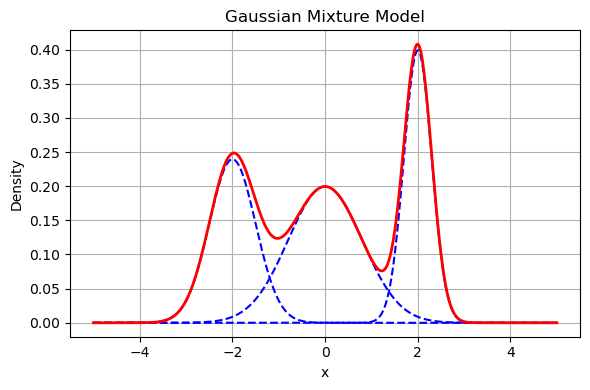

In [174]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the mixture components
weights = [0.3, 0.4, 0.3]            # must sum to 1
means = [-2, 0, 2]
stds = [0.5, 0.8, 0.3]

# X axis for plotting
x = np.linspace(-5, 5, 1000)

# Compute individual Gaussians (scaled by weights)
components = [w * norm.pdf(x, loc=mu, scale=std)
              for w, mu, std in zip(weights, means, stds)]

# Compute mixture
mixture = np.sum(components, axis=0)

# Plot
plt.figure(figsize=(6, 4))

# Plot each component in blue
for i, comp in enumerate(components):
    plt.plot(x, comp, 'b--')

# Plot mixture in red
plt.plot(x, mixture, 'r-', linewidth=2)

plt.title("Gaussian Mixture Model")
plt.xlabel('x')
plt.ylabel('Density')
plt.grid(True)
plt.tight_layout()
plt.show()


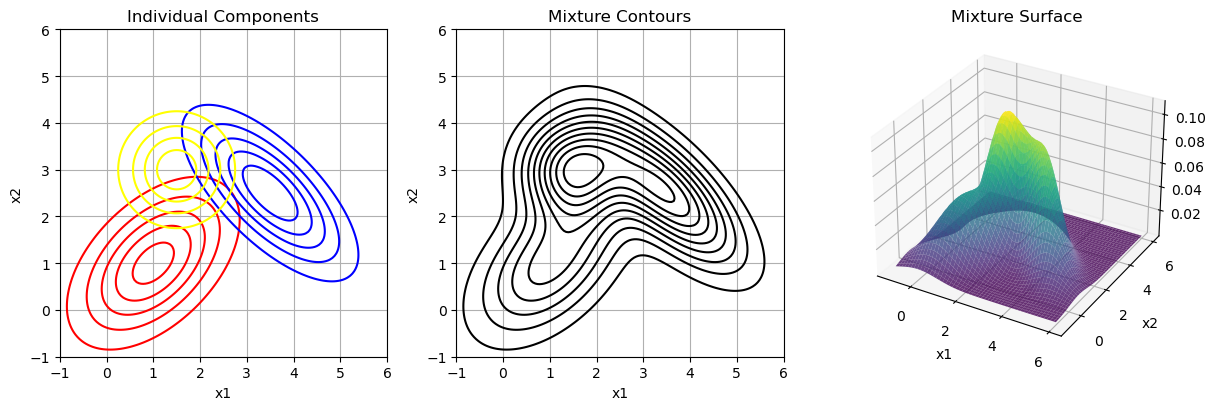

In [ ]:
# Mixture of 3 Gaussian
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection

# Parameters
weights = [0.3, 0.4, 0.3]
means = [np.array([1, 1]), np.array([3.5, 2.5]), np.array([1.5, 3])]
covs = [
    [[1, 0.5], [0.5, 1]],
    [[1, -0.7], [-0.7, 1]],
    [[0.5, 0], [0, 0.5]]
]

# Grid
x = np.linspace(-1, 6, 150)
y = np.linspace(-1, 6, 150)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

# Components and mixture
components = [w * multivariate_normal(mean=mu, cov=cov).pdf(pos)
              for w, mu, cov in zip(weights, means, covs)]
mixture_pdf = np.sum(components, axis=0)

# Create individual subplots
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

# Individual components
colors = ['red', 'blue', 'yellow']
for i, comp in enumerate(components):
    ax1.contour(X, Y, comp, colors=colors[i], levels=5)
#    ax1.text(means[i][0], means[i][1] - 0.5, f'w = {weights[i]:.2f}', color=colors[i], fontsize=12, ha='center')
ax1.set_title('Individual Components')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_aspect('equal')
ax1.grid(True)

# Mixture contours
ax2.contour(X, Y, mixture_pdf, colors='black', levels=10)
ax2.set_title('Mixture Contours')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_aspect('equal')
ax2.grid(True)

# 3D Surface plot
ax3.plot_surface(X, Y, mixture_pdf, cmap='viridis', edgecolor='none', alpha=0.8)
ax3.set_title('Mixture Surface')
ax3.set_xlabel('x1')
ax3.set_ylabel('x2')

plt.tight_layout()
plt.show()


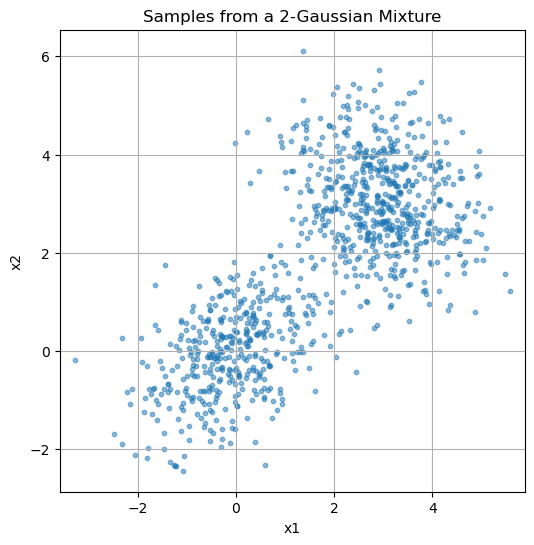

In [189]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Set seed for reproducibility
np.random.seed(42)

# Mixture parameters
weights = [0.4, 0.6]  # mixing coefficients
means = [np.array([0, 0]), np.array([3, 3])]
covs = [np.array([[1, 0.5], [0.5, 1]]), np.array([[1, -0.3], [-0.3, 1]])]

# Number of samples
N = 1000

# Step 1: Choose components
components = np.random.choice([0, 1], size=N, p=weights)

# Step 2: Sample from the corresponding Gaussian
samples = np.array([
    np.random.multivariate_normal(mean=means[k], cov=covs[k])
    for k in components
])

# Plot the result
plt.figure(figsize=(6, 6))
plt.scatter(samples[:, 0], samples[:, 1], s=10, alpha=0.5)
#plt.plot(samples)
plt.title('Samples from a 2-Gaussian Mixture')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')
plt.grid(True)
plt.show()


An illustration of the histogram approach to density estimation, in which a data set of 50 data points is generated from the mixture of Gaussian distribution. Below we can look at different results for $\Delta$ in
$$ p_i = \frac{n_i}{N\Delta}$$
where $n_i$ are the number of points in the $i$-th bin.

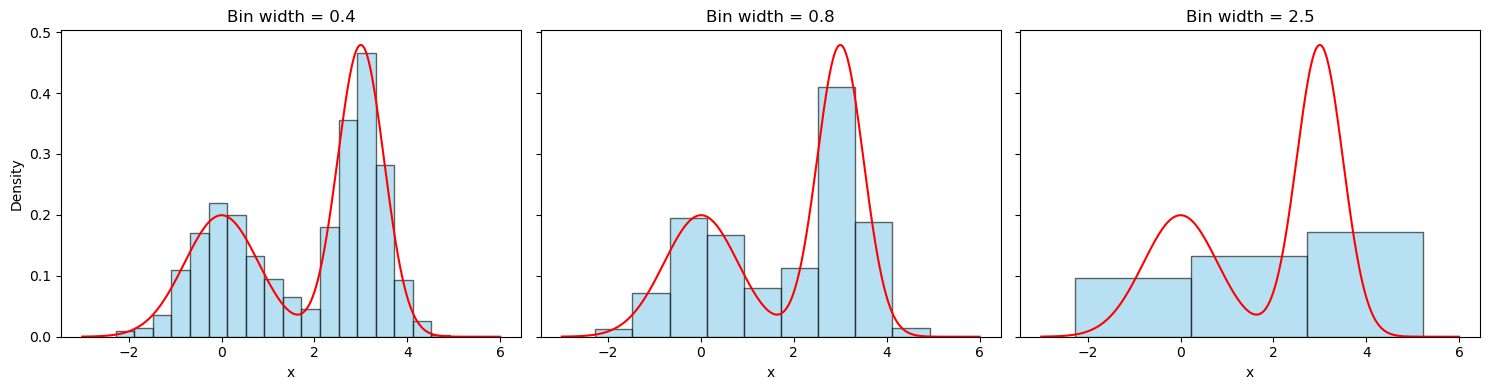

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Gaussian Mixture Model ---
weights = [0.4, 0.6]
means = [0, 3]
stds = [0.8, 0.5]

np.random.seed(42)
N = 1000
components = np.random.choice([0, 1], size=N, p=weights)
samples = np.array([np.random.normal(means[k], stds[k]) for k in components])

x_vals = np.linspace(-3, 6, 1000)
pdf = (
    weights[0] * multivariate_normal.pdf(x_vals, mean=means[0], cov=stds[0]**2) +
    weights[1] * multivariate_normal.pdf(x_vals, mean=means[1], cov=stds[1]**2)
)

bin_widths = [0.4, 0.8, 2.5]
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, bw in zip(axs, bin_widths):
    bins = np.arange(min(samples), max(samples) + bw, bw)
    ax.hist(samples, bins=bins, density=True, alpha=0.6, color='skyblue', edgecolor='black')
    ax.plot(x_vals, pdf, 'r-')
    ax.set_title(f'Bin width = {bw}')
    ax.set_xlabel('x')

axs[0].set_ylabel('Density')
plt.tight_layout()
plt.show()


Another approach to density estimation beside the histogram approach is the so-called Kernel Density Estimation (KDE), which makes use of a given kernel in order to approximate a target density.
$$ p(\mathbf{x}) = \frac{1}{Nh}\sum_{n=1}^N k\left( \frac{\mathbf{x}-\mathbf{x}_n}{h} \right) $$
where $h$ is called bandwidth or smoothing parameter. Many kernels are available, and depending on the chosen kernel a different estimate may appear; one of the most used kernel is (clearly) the Gaussian kernel:
$$ p(\mathbf{x}) = \frac{1}{N}\sum_{n=1}^N  \frac{1}{(2\pi h^2)^{1/2}} \exp\left( -\frac{\Vert\mathbf{x}-\mathbf{x}_n \Vert}{2h^2} \right) $$

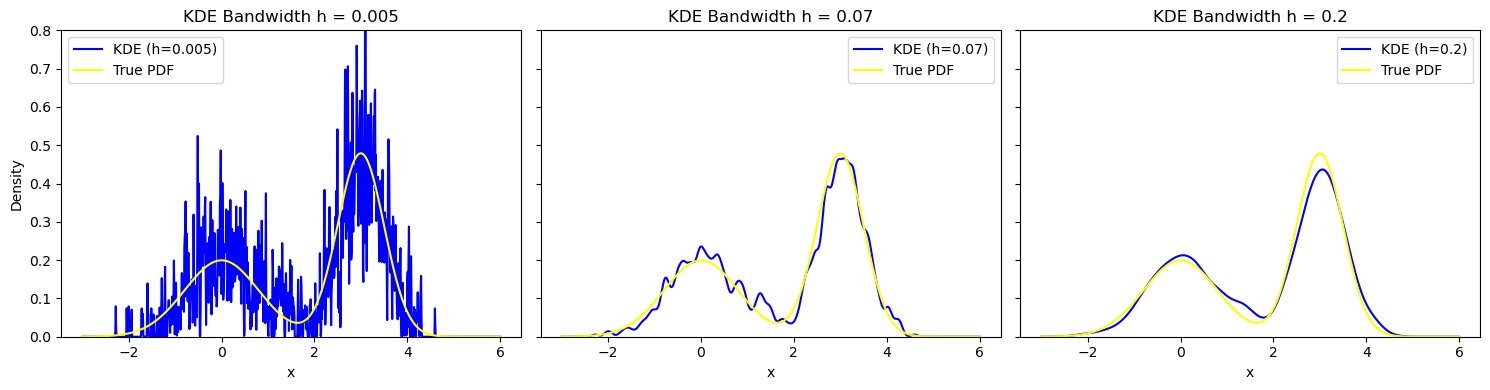

In [9]:
# KDE with different bandwidths
from scipy.stats import gaussian_kde

bandwidths = [0.005, 0.07, 0.2]
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, bw in zip(axs, bandwidths):
    kde = gaussian_kde(samples, bw_method=bw / np.std(samples))  # Normalize bandwidth
    kde_vals = kde(x_vals)

    ax.plot(x_vals, kde_vals, label=f'KDE (h={bw})', color='blue')
    ax.plot(x_vals, pdf, 'yellow', label='True PDF')
    ax.set_title(f'KDE Bandwidth h = {bw}')
    ax.set_xlabel('x')
    ax.set_ylim(0,0.8)
    ax.legend()

axs[0].set_ylabel('Density')
plt.tight_layout()

One of the difficulties with the kernel approach to density estimation is that the parameter $h$ governing the kernel width is fixed for all kernels: an optimal choice for $h$ may be dependent on location within the data space.  In the $K$-nearestneighbour classifier, a new point is classified according to the majority class membership of the $K$ closest training data points. We have the following distributions of interest,
$$ p(\mathbf{x}\mid \mathcal{C}_k) = \frac{K_k}{N_k V}, \quad p(\mathbf{x}) = \frac{K}{NV}, \quad p(\mathcal{C}_k) = \frac{N_k}{N} $$
then according to Bayes' theorem
$$ p(\mathcal{C}_k \mid \mathbf{x}) = \frac{p(\mathbf{x}|\mathcal{C}_k) p(\mathcal{C}_k)}{p(\mathbf{x})} = \frac{K_k}{N_k V} \frac{N_k}{N} \frac{NV}{K} = \frac{K_k}{K} $$

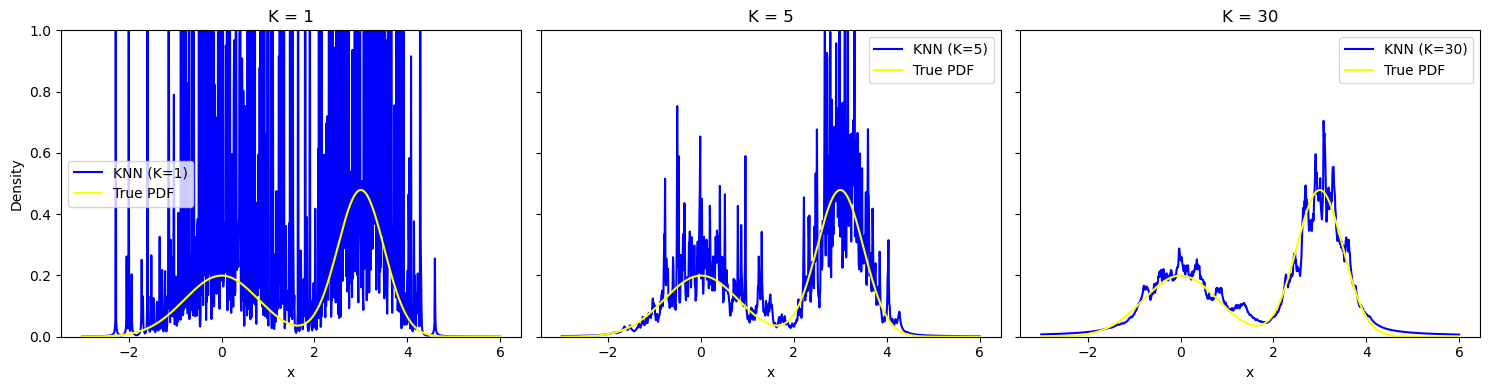

In [14]:
from sklearn.neighbors import NearestNeighbors

# Reshape for NearestNeighbors
samples_reshaped = samples.reshape(-1, 1)
x_query = x_vals.reshape(-1, 1)

# KNN parameters
K_values = [1, 5, 30]
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, K in zip(axs, K_values):
    nbrs = NearestNeighbors(n_neighbors=K)
    nbrs.fit(samples_reshaped)

    # Find distances to Kth neighbor for each x
    distances, _ = nbrs.kneighbors(x_query)
    d_k = distances[:, -1]  # Kth nearest distance for each x

    # KNN density estimate
    f_hat = K / (N * 2 * d_k)

    ax.plot(x_vals, f_hat, label=f'KNN (K={K})', color='blue')
    ax.plot(x_vals, pdf, 'yellow', label='True PDF')
    ax.set_title(f'K = {K}')
    ax.set_xlabel('x')
    ax.set_ylim(0,1)
    ax.legend()

axs[0].set_ylabel('Density')
plt.tight_layout()
plt.show()